(08-39-wat-we-niet-weten)=

# Wat we niet weten

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1981–2026, van Shillers excess volatility en de puzzel van Mehra en Prescott tot de
terugblik van Santa-Clara.

**Wat we al weten.** [De vorige lecture](#08-38-wat-we-weten) zette elf stellingen op een rij die na
anderhalve eeuw overeind staan. Wat een belegger *niet* moet doen, staat met hoge zekerheid vast;
hoe groot een beloning is, weten we maar op een paar procentpunt nauwkeurig. De barsten die niet
zijn opgeruimd, zijn blijven liggen.

**Welke vraag staat open.** Welke vragen kan het vak na anderhalve eeuw niet beantwoorden, en welke
data of welk experiment zou ze beslissen?

Ook deze synthese wijkt af van de vaste opbouw. Het toy-voorbeeld is één overkoepelend geval van
observationele equivalentie: twee verklaringen, dezelfde prijzen. De theorie bestaat uit twee korte
proposities, over wat prijzen wel en niet identificeren en over hoeveel jaar data een beslissende
toets vraagt. De simulatie rekent dat uit voor de drie belangrijkste vragen. De replicatie bestaat uit
dertien korte demonstraties, één per open vraag.
```

## Overzicht

Santa-Clara sluit zijn terugblik af met een tweede lijst {cite}`SantaClara2026`. Hij introduceert
haar zo: *"The second list is the honest one, and it is the reason the field is still worth working
in."* Het zijn dertien vragen, van de omvang van de equity premium tot de vraag welke bedrijven
kunstmatige intelligentie zal vervangen. De lijst is het spiegelbeeld van die in
[](#08-38-wat-we-weten). Daar stonden feiten waarover iedereen het eens is. Hier staan feiten die
evenmin ter discussie staan, maar waarvoor twee of meer verklaringen concurreren die met de
beschikbare data niet te scheiden zijn.

Dat is de epistemische eindtoestand van de reeks (motief 3). Het vak begon met een theorie die
getoetst werd, het CAPM, en eindigt met een lijst feiten die op een verklaring wachten. Santa-Clara
vat het samen als een vak dat "very good at establishing facts and very bad at agreeing on their
meaning" is.

Per vraag geven we (a) de vraag, in Santa-Clara's woorden; (b) de concurrerende verklaringen, zonder
te kiezen (motief 2); (c) één compacte demonstratie op de gecachte data, met de aanpak van de lecture
waar het onderwerp werd behandeld; en (d) welke data of welk experiment de verklaringen zou scheiden,
en waarom we die niet hebben. Voor de equity premium, risico of vergissing in de cross-sectie en de
verzwakking van anomalieën rekent de simulatie uit hoeveel jaar data een beslissende toets vraagt.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20260914)

## Intuïtie: waarom zou dit waar zijn?

Er zijn drie redenen waarom een vraag in dit vak open blijft, en elke vraag op de lijst struikelt
over minstens één ervan.

De eerste is dat *een prijs twee dingen tegelijk samenvat*: hoe waarschijnlijk beleggers een toestand
vinden, en hoeveel een euro in die toestand voor hen waard is. Een aandeel kan goedkoop zijn omdat het
slecht betaalt wanneer een euro veel waard is (risico), of omdat beleggers de kans op die slechte
toestand overschatten (vergissing). Prijzen en rendementen tonen het product, niet de factoren. Dat is
motief 2 in zijn kaalste vorm. Scheiden kan pas als een van beide apart gemeten wordt, het marginale
nut uit consumptie of de verwachtingen uit enquêtes, en beide metingen zijn slecht.

De tweede is statistisch, motief 1 op zijn scherpst. De toetsen die verklaringen zouden scheiden, gaan
over eerste momenten, zeldzame gebeurtenissen of episodes die in clusters komen. Een eeuw data is
honderd jaar voor het gemiddelde, zestien recessies en een handvol crashes.

De derde is dat het beslissende experiment niet uit te voeren is. Niemand kan geld willekeurig over
fondsen verdelen, publicatie van een anomalie willekeurig uitstellen, of een gebouw dagelijks
verhandelen om zijn volatiliteit te meten. Wat niet verhandeld wordt, heeft geen prijs om te toetsen.

## Toy-voorbeeld: twee verklaringen, dezelfde prijzen

Er zijn twee toestanden op $t+1$, "goed" en "slecht", en een econometrist die na een eeuw data weet
dat ze elk met kans $\pi = (0{,}5;\ 0{,}5)$ voorkomen. Er zijn twee activa: een obligatie met payoff
$(1{,}00;\ 1{,}00)$ en een value-aandeel met payoff $(1{,}30;\ 0{,}80)$.

**Verklaring R (risico).** Beleggers kennen de kansen en hebben een SDF die hoog is in de slechte
toestand, $m = (0{,}85;\ 1{,}05)$. De *toestandsprijzen* (de prijs vandaag van één euro in één
toestand) zijn $q_s = \pi_s m_s$, dus $q = (0{,}425;\ 0{,}525)$. De obligatie kost
$0{,}425 + 0{,}525 = 0{,}95$, dus $R^f = 1/0{,}95 = 1{,}0526$. Het value-aandeel kost
$0{,}425 \times 1{,}30 + 0{,}525 \times 0{,}80 = 0{,}5525 + 0{,}42 = 0{,}9725$. Het verwachte
bruto rendement is $(0{,}5 \times 1{,}30 + 0{,}5 \times 0{,}80)/0{,}9725 = 1{,}05/0{,}9725 = 1{,}0797$,
een premie van 2,71 procentpunt, als beloning voor een payoff die laag is wanneer een euro veel
waard is.

**Verklaring V (vergissing).** Beleggers zijn risiconeutraal, $m^\ast = 0{,}95$ in beide toestanden,
maar ze overschatten de kans op de slechte toestand. Hun subjectieve kansen $\tilde\pi$ volgen uit
dezelfde toestandsprijzen: $\tilde\pi_s = q_s/m^\ast$, dus $\tilde\pi = (0{,}425/0{,}95;\ 0{,}525/0{,}95)
= (0{,}4474;\ 0{,}5526)$. De obligatie kost weer $0{,}95$, en het value-aandeel
$0{,}95 \times (0{,}4474 \times 1{,}30 + 0{,}5526 \times 0{,}80) = 0{,}95 \times 1{,}0237 = 0{,}9725$.

Beide verklaringen geven dezelfde prijzen. Omdat de econometrist de ware kansen kent, ziet hij in
beide werelden hetzelfde verwachte rendement van 7,97% en dezelfde premie van 2,71 procentpunt. In
wereld R is de premie een beloning die blijft bestaan. In wereld V is het een fout die verdwijnt
zodra beleggers hun kansen bijstellen, en die een arbitrageur met genoeg kapitaal nu al kan oogsten.
Geen enkele tijdreeks van prijzen en rendementen uit deze economie kan zeggen in welke wereld we
leven.

In [2]:
prob = np.array([0.5, 0.5])                       # true state probabilities, known to the econometrician
payoffs = np.array([[1.00, 1.00],                 # bond
                    [1.30, 0.80]])                # value stock

m_risk = np.array([0.85, 1.05])                   # story R: rational beliefs, state-dependent SDF
q = prob * m_risk                                 # state prices
m_flat = q.sum()                                  # story V: risk-neutral SDF ...
prob_belief = q / m_flat                          # ... with distorted beliefs

prices_r = payoffs @ (prob * m_risk)
prices_v = payoffs @ (prob_belief * m_flat)
expected_return = (payoffs @ prob) / prices_r
print(f"toestandsprijzen q        = {q.round(4)}")
print(f"prijzen R (risico)        = {prices_r.round(4)}")
print(f"prijzen V (vergissing)    = {prices_v.round(4)}")
print(f"subjectieve kansen in V   = {prob_belief.round(4)}")
print(f"R^f = {1 / q.sum():.4f}, E[R] value = {expected_return[1]:.4f}, "
      f"premie = {100 * (expected_return[1] - 1 / q.sum()):.2f} procentpunt")
print("prijzen identiek:", np.allclose(prices_r, prices_v))

toestandsprijzen q        = [0.425 0.525]
prijzen R (risico)        = [0.95   0.9725]
prijzen V (vergissing)    = [0.95   0.9725]
subjectieve kansen in V   = [0.4474 0.5526]
R^f = 1.0526, E[R] value = 1.0797, premie = 2.71 procentpunt
prijzen identiek: True


De code reproduceert de handberekening. Het voorbeeld is het patroon achter bijna elke vraag
hieronder. Vervang "value-aandeel" door "de markt" en het is vraag 1, door "een anomalie" en het is
vraag 2, door "een industrie na een verdubbeling" en het is vraag 7.

## Theorie

### Wat prijzen identificeren

*Waarom zou dit waar zijn?* Een prijs is een som over toestanden van payoff maal wat die toestand
vandaag kost. Wat een toestand kost, hangt af van hoe waarschijnlijk hij is en van hoeveel een euro
daar waard is, maar alleen hun product komt in de prijs. Elke herverdeling tussen die twee die het
product ongemoeid laat, is onzichtbaar.

:::{prf:proposition} Observationele equivalentie van kansen en SDF
:label: thm-wat-we-niet-weten-equivalentie

Laat er $S$ toestanden zijn met ware kansen $\pi_s > 0$ en een SDF $m_s > 0$, zodat elke payoff
$x$ de prijs $p(x) = \sum_s \pi_s m_s x_s$ heeft. Voor elke kansverdeling $\tilde\pi$ met
$\tilde\pi_s > 0$ bestaat een unieke SDF $\tilde m$ zodat

```{math}
:label: eq-wat-we-niet-weten-toestandsprijs
\sum_s \tilde\pi_s \tilde m_s x_s = \sum_s \pi_s m_s x_s \quad \text{voor elke } x,
\qquad \tilde m_s = \frac{\pi_s m_s}{\tilde\pi_s} .
```

De prijzen van alle activa, en de verdeling van hun rendementen onder $\pi$, zijn daarom
dezelfde onder $(\pi, m)$ en $(\tilde\pi, \tilde m)$. In het bijzonder is er altijd een
verklaring met risiconeutrale beleggers ($\tilde m$ constant) en verkeerde kansen.
:::

:::{prf:proof}
Beide kanten zijn lineair in $x$; neem voor $x$ de eenheidsvector van toestand $s$. Dan moet
$\tilde\pi_s \tilde m_s = \pi_s m_s = q_s$ gelden voor elke $s$, en dat bepaalt $\tilde m_s$ uniek.
De rendementen hangen alleen van $x$ en $p(x)$ af, en hun verdeling onder de ware kansen $\pi$ is in
beide gevallen dezelfde. Kies $\tilde\pi_s = q_s/\sum_j q_j$ en $\tilde m_s = \sum_j q_j$ voor de
risiconeutrale verklaring. $\square$
:::

De propositie is de formele kern van motief 2. Ze zegt ook wat de kampen *wel* zou scheiden: een
onafhankelijke meting van $m$ (uit consumptie, zoals in [](#03-12-consumptie-capm)), een
onafhankelijke meting van $\tilde\pi$ (uit enquêtes, zoals in [](#05-33-fama-vs-shiller)), of een
schok aan één kant, zoals een instroom van arbitragekapitaal die een vergissing wel en een
risicopremie niet zou wegnemen. Elke "wat zou beslissen" hieronder is een van die drie.

### Hoeveel jaar een beslissende toets vraagt

*Waarom zou dit waar zijn?* Stel dat twee verklaringen voorspellingen doen over het gemiddelde van
een grootheid die we elk jaar waarnemen: het rendement van value in recessies, of het rendement van
anomalieën vóór publicatie. Het verschil tussen de voorspellingen is een vast getal; de ruis in het
steekproefgemiddelde krimpt met de wortel van het aantal jaren. Er is dus altijd een steekproef die
lang genoeg is. De vraag is of die langer is dan de geschiedenis.

:::{prf:proposition} Steekproeflengte voor een gegeven onderscheidingsvermogen
:label: thm-wat-we-niet-weten-kracht

Laat $d_1, \dots, d_T$ jaarlijkse waarnemingen zijn met gemiddelde $\delta_0$ onder hypothese $H_0$ en
$\delta_1$ onder $H_1$, en met *langetermijnvariantie* $\bar\sigma^2 = \sum_{j=-\infty}^{\infty}
\Cov(d_t, d_{t-j})$ onder beide. Een tweezijdige toets van $H_0$ met omvang $\alpha$ op het
steekproefgemiddelde heeft asymptotisch onderscheidingsvermogen (kracht) $\kappa$ tegen $H_1$ zodra

```{math}
:label: eq-wat-we-niet-weten-jaren
T \ \ge\ T^\ast = \left(z_{1-\alpha/2} + z_{\kappa}\right)^2 \frac{\bar\sigma^2}{(\delta_1 - \delta_0)^2} .
```

Voor $\alpha = 5\%$ en $\kappa = 80\%$ is $(z_{0,975} + z_{0,80})^2 = (1{,}960 + 0{,}842)^2 = 7{,}85$.
:::

:::{prf:proof}
Onder $H_1$ is $\sqrt{T}(\bar d - \delta_0)/\bar\sigma$ asymptotisch normaal met verwachting
$\sqrt{T}\Delta/\bar\sigma$, $\Delta = \delta_1 - \delta_0$, en variantie één. De toets verwerpt als de
absolute waarde groter is dan $z_{1-\alpha/2}$. Verwaarloos de verwerping aan de verkeerde kant, die
een kans kleiner dan $\alpha/2$ heeft; dan is de kracht $\Phi(\sqrt{T}|\Delta|/\bar\sigma -
z_{1-\alpha/2})$, en die is minstens $\kappa$ als $\sqrt{T}|\Delta|/\bar\sigma - z_{1-\alpha/2} \ge
z_\kappa$. Kwadrateren geeft [](#eq-wat-we-niet-weten-jaren). $\square$
:::

Twee dingen maken de formule onvriendelijk. Het verschil $\Delta$ is klein, omdat beide verklaringen
hetzelfde gemiddelde rendement moeten verklaren; alleen een voorwaardelijk gemiddelde of een hoger
moment verschilt. En $\bar\sigma^2$ is groter dan de gewone variantie zodra gebeurtenissen in clusters
komen: tien recessiemaanden in één episode zijn ongeveer één waarneming. [](#08-38-wat-we-weten) vroeg
hoe lang het duurt om een premie te *zien*; hier gaat het om het duurdere probleem, twee verklaringen
van dezelfde premie *scheiden*.

## Simulatie: hoeveel jaar voor 80% onderscheidingsvermogen

Voor elk van de drie vragen kiezen we één paar hypotheses met parameters in de orde van grootte van de
data, en simuleren we per steekproeflengte de kracht van een toets met omvang 5%. De kritieke waarden
komen uit de simulatie onder de nulhypothese, zodat scheefheid en clustering in de toets zitten.

**Vraag 1.** Rampen {cite}`Rietz1988,Barro2006` tegenover een lognormaal jaarrendement, zoals in habit
en long-run risk ([](#05-27-drie-antwoorden)), met hetzelfde gemiddelde (6%) en dezelfde volatiliteit
(20%). Een ramp verlaagt het logrendement met $b$, met Barro's kans $p = 0{,}017$ per jaar. De toets is
eenzijdig, op de scheefheid.

**Vraag 2.** Als de value-premie een risicopremie is, presteert value slecht in recessies; als ze een
vergissing is, niet noodzakelijk. Onder $H_1$ ligt het maandrendement van HML in recessies 1
procentpunt lager, onder $H_0$ niet. Recessies duren gemiddeld 14 maanden, expansies 70 (17% van de
maanden recessie, zoals sinds 1926). Elke episode heeft een eigen afwijking met standaardafwijking 1
procentpunt; de maandruis is 3,55%, de volatiliteit van HML.

**Vraag 4.** Bij arbitrage verdient een anomalie tussen steekproefeinde en publicatie nog haar volle
in-sample rendement (0,69% per maand in [](#06-34-factor-zoo)); bij datamining al het lagere
post-publicatierendement (0,30%). We toetsen het gemiddelde in dat tussenvenster voor 1, 10 en 212
signalen, met maandvolatiliteit 3,3% en onderlinge correlatie 0,04, beide gemeten in de replicatie.

In [3]:
N_SIM = 2000


def years_for_power(grid, power, target=0.8):
    """Linear interpolation of the smallest grid value where simulated power reaches `target`."""
    power = np.asarray(power)
    if power[-1] < target:
        return np.nan
    i = int(np.argmax(power >= target))
    if i == 0:
        return float(grid[0])
    return float(np.interp(target, power[i - 1:i + 1], grid[i - 1:i + 1]))


# Question 1: skewness of annual log returns, disasters versus lognormal with the same mean and variance
YEARS_Q1 = np.array([50, 100, 200, 400, 800])


def power_skewness(b, p_disaster=0.017, mu=0.06, sd=0.20):
    sd_normal = np.sqrt(sd**2 - p_disaster * (1 - p_disaster) * b**2)
    out = []
    for T in YEARS_Q1:
        crit = np.quantile(stats.skew(rng.normal(mu, sd, (N_SIM, T)), axis=1), 0.05)
        jumps = rng.random((N_SIM, T)) < p_disaster
        alt = mu + p_disaster * b + sd_normal * rng.standard_normal((N_SIM, T)) - b * jumps
        out.append(np.mean(stats.skew(alt, axis=1) < crit))
    return np.array(out)


power_q1 = {b: power_skewness(b) for b in (0.3, 0.5, 0.7)}
pd.DataFrame(power_q1, index=YEARS_Q1).rename_axis("jaren").rename(columns=lambda b: f"ramp b = {b}").round(2)

,ramp b = 0.3,ramp b = 0.5,ramp b = 0.7
jaren,,,
50,0.07,0.20,0.42
100,0.08,0.25,0.63
200,0.10,0.39,0.81
400,0.14,0.56,0.97
800,0.16,0.82,1.00


In [4]:
# Question 2: HML in recessions versus expansions, with recessions clustered in episodes
YEARS_Q2 = np.array([25, 50, 100, 150, 200, 300, 400])


def recession_gap(T, shift, sigma=0.0355, tau=0.01, exp_len=70, rec_len=14):
    """Mean HML return in recession months minus expansion months, one value per simulated sample."""
    months = 12 * T
    n_cycles = int(2 * months / (exp_len + rec_len)) + 20
    exp_d = rng.geometric(1 / exp_len, (N_SIM, n_cycles))
    rec_d = rng.geometric(1 / rec_len, (N_SIM, n_cycles))
    rec_end = np.cumsum(exp_d + rec_d, axis=1)
    rec_in = np.clip(np.minimum(rec_end, months) - (rec_end - rec_d), 0, None)   # recession months in sample
    episode_shift = rng.normal(shift, tau, (N_SIM, n_cycles))
    n_rec = rec_in.sum(axis=1)
    n_exp = months - n_rec
    sum_rec = sigma * np.sqrt(n_rec) * rng.standard_normal(N_SIM) + (episode_shift * rec_in).sum(axis=1)
    sum_exp = sigma * np.sqrt(n_exp) * rng.standard_normal(N_SIM)
    ok = n_rec > 0
    return sum_rec[ok] / n_rec[ok] - sum_exp[ok] / n_exp[ok]


power_q2 = []
for T in YEARS_Q2:
    lo, hi = np.quantile(recession_gap(T, 0.0), [0.025, 0.975])
    alt = recession_gap(T, -0.01)
    power_q2.append(np.mean((alt < lo) | (alt > hi)))

# Question 4: mean return between sample end and publication, arbitrage (0.69%) versus data mining (0.30%)
WINDOWS = np.array([1, 2, 5, 10, 20, 40, 60])


def window_mean(W, n_signals, mu, sigma=0.033, rho=0.04):
    months = int(12 * W)
    common = rng.standard_normal((N_SIM, months))
    own = rng.standard_normal((N_SIM, months))
    return mu + sigma * (np.sqrt(rho) * common + np.sqrt((1 - rho) / n_signals) * own).mean(axis=1)


power_q4 = {}
for n_signals in (1, 10, 212):
    row = []
    for W in WINDOWS:
        lo, hi = np.quantile(window_mean(W, n_signals, 0.0030), [0.025, 0.975])
        alt = window_mean(W, n_signals, 0.0069)
        row.append(np.mean((alt < lo) | (alt > hi)))
    power_q4[n_signals] = np.array(row)

z2 = (stats.norm.ppf(0.975) + stats.norm.ppf(0.80)) ** 2          # two-sided, 7.85
z1 = (stats.norm.ppf(0.95) + stats.norm.ppf(0.80)) ** 2           # one-sided, for the skewness test


def disaster_skewness(b, p=0.017, sd=0.20):
    """Population skewness of annual log returns with a Bernoulli(p) drop of size b and total volatility sd."""
    return -(b**3) * p * (1 - p) * (1 - 2 * p) / sd**3


s = 14 / 84                                                        # share of recession months
summary = pd.DataFrame({
    "simulatie (jaar)": [years_for_power(YEARS_Q1, power_q1[0.5]), years_for_power(YEARS_Q1, power_q1[0.7]),
                         years_for_power(YEARS_Q2, power_q2),
                         years_for_power(WINDOWS, power_q4[1]), years_for_power(WINDOWS, power_q4[10]),
                         years_for_power(WINDOWS, power_q4[212])],
    "formule, normale benadering (jaar)": [
        z1 * 6 / disaster_skewness(0.5) ** 2, z1 * 6 / disaster_skewness(0.7) ** 2,
        z2 * 0.0355**2 / 12 * (1 / s + 1 / (1 - s)) / 0.01**2,
        z2 * 0.033**2 / 12 / 0.0039**2, z2 * 0.033**2 * (0.04 + 0.96 / 10) / 12 / 0.0039**2,
        z2 * 0.033**2 * (0.04 + 0.96 / 212) / 12 / 0.0039**2],
}, index=["1: rampen b = 0,5 tegen lognormaal", "1: rampen b = 0,7 tegen lognormaal",
          "2: HML in recessies (simulatie met, formule zonder clustering)", "4: tussenvenster, 1 signaal",
          "4: tussenvenster, 10 signalen", "4: tussenvenster, 212 signalen"])
summary.round(1)

,simulatie (jaar),"formule, normale benadering (jaar)"
"1: rampen b = 0,5 tegen lognormaal",769.5,583.1
"1: rampen b = 0,7 tegen lognormaal",193.2,77.4
"2: HML in recessies (simulatie met, formule zonder clustering)",167.9,59.3
"4: tussenvenster, 1 signaal",50.0,46.8
"4: tussenvenster, 10 signalen",7.2,6.4
"4: tussenvenster, 212 signalen",2.4,2.1


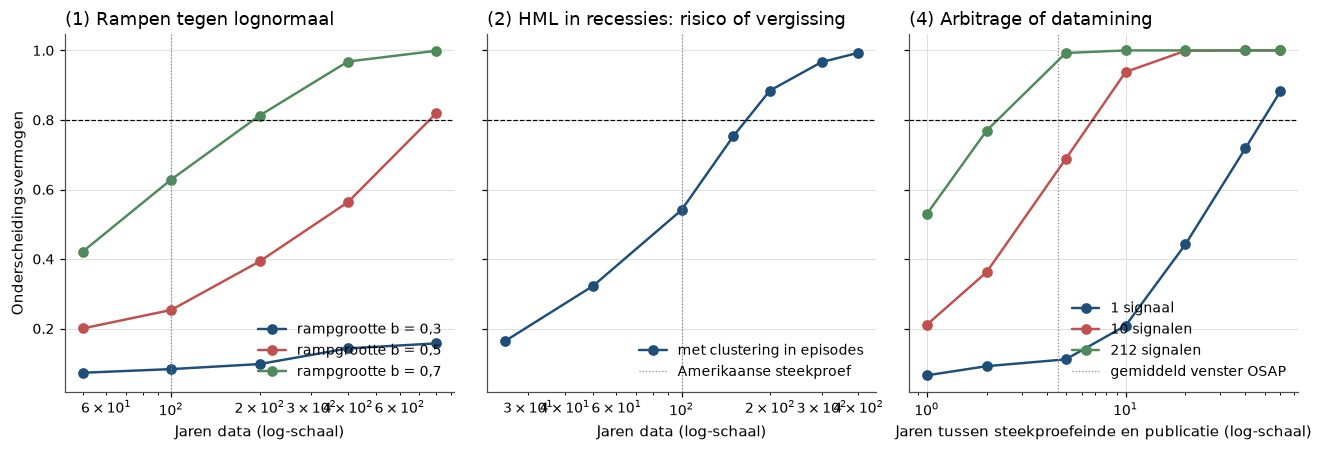

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), sharey=True)
for b, power in power_q1.items():
    axes[0].plot(YEARS_Q1, power, marker="o", label=f"rampgrootte b = {b}".replace(".", ","))
axes[0].axvline(100, color="grey", lw=0.8, ls=":")
axes[0].set_xscale("log")
axes[0].set_title("(1) Rampen tegen lognormaal")
axes[0].set_xlabel("Jaren data (log-schaal)")
axes[0].set_ylabel("Onderscheidingsvermogen")

axes[1].plot(YEARS_Q2, power_q2, marker="o", color=hap.plotting.COLORS[0], label="met clustering in episodes")
axes[1].axvline(100, color="grey", lw=0.8, ls=":", label="Amerikaanse steekproef")
axes[1].set_xscale("log")
axes[1].set_title("(2) HML in recessies: risico of vergissing")
axes[1].set_xlabel("Jaren data (log-schaal)")

for n_signals, power in power_q4.items():
    axes[2].plot(WINDOWS, power, marker="o", label=f"{n_signals} signa{'al' if n_signals == 1 else 'len'}")
axes[2].axvline(4.55, color="grey", lw=0.8, ls=":", label="gemiddeld venster OSAP")
axes[2].set_xscale("log")
axes[2].set_title("(4) Arbitrage of datamining")
axes[2].set_xlabel("Jaren tussen steekproefeinde en publicatie (log-schaal)")
for ax in axes:
    ax.axhline(0.8, color="black", lw=0.8, ls="--")
    ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

:::{figure} #cel-wat-we-niet-weten-kracht
:label: fig-wat-we-niet-weten-kracht
:width: 100%

Onderscheidingsvermogen van de drie toetsen als functie van de steekproeflengte; de gestreepte lijn
is 80%, de gestippelde de lengte van de beschikbare data. Links en in het midden ligt 80% ver voorbij
een eeuw. Rechts is de toets over 212 signalen al na tweeënhalf jaar sterk, maar voor één signaal
pas na tientallen jaren.
:::

**Rampen tegen lognormaal.** Een ramp van $b = 0{,}5$ maakt de jaarrendementen maar licht scheef: met
een eeuw data heeft de toets 25% kracht, voor 80% zijn ongeveer 770 jaar nodig. Bij $b = 0{,}7$ zijn
het er ongeveer 190, bij $b = 0{,}3$ is de kracht na 800 jaar 16%. De normale benadering van
[](#eq-wat-we-niet-weten-jaren) onderschat de benodigde lengte, omdat de steekproefscheefheid onder
rampen zelf een dikke staart heeft. Dit is het *peso-probleem* (een zeldzame toestand die prijzen
stuurt maar in de steekproef nauwelijks voorkomt).

**HML in recessies.** Zonder clustering zou een recessie-effect van 1 procentpunt per maand na ongeveer
59 jaar met 80% kracht te zien zijn; met episodes die elk hun eigen afwijking hebben, na ongeveer 170
jaar. Zestien recessies zijn zestien waarnemingen.

**Arbitrage of datamining.** Hier helpt de breedte van de cross-sectie. Over 212 signalen zijn de twee
zuivere hypotheses na tweeënhalf jaar te scheiden, binnen het gemiddelde venster van 4,55 jaar; voor
één signaal is ongeveer 50 jaar nodig. Het vak kan dus zeggen hoe anomalieën *gemiddeld* verzwakken,
maar niet waarom één bepaalde anomalie verzwakte, en ook niet hoe de twee mechanismen bijdragen als ze
tegelijk werken.

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** De dertien vragen uit de sectie "What we do not know" van {cite:t}`SantaClara2026`. Per
vraag de aanpak van de lecture in de samenvattende tabel aan het eind; daarnaast de industriebellen
van {cite:t}`GreenwoodShleiferYou2019` (vraag 7), het appraisal smoothing-model van
{cite:t}`Geltner1993` en {cite:t}`GetmanskyLoMakarov2004` (vraag 9), de gemiddelde variantie van
{cite:t}`GoyalSantaClara2003` (vraag 10) en de event study van {cite:t}`EisfeldtSchubertZhang2023`
(vraag 12).

**Wat.** Per vraag één tabel: de puzzel zelf, met standaardfouten, niet het antwoord.

**Data hier.** Goyal-Welch (jaarlijks), FRED (NBER-recessies, consumptie, lonen `A576RC1`, huizenprijzen
`USSTHPI`, CPI, Financial Accounts), French (FF3, 10 en 49 industrieën, maand- en dagdata), OSAP
(portefeuilles en documentatie), Shiller (CAPE), Yahoo (de 50 aandelen uit
[](#07-37-llms-en-efficientie)) en de CFO-enquête uit [](#05-33-fama-vs-shiller), alles via
`hap.data` of de cache. Voor vraag 9 bestaan geen gratis appraisal-data; we smoothen een reeks die we
zelf uit het kwartaalrendement van de markt bouwen.

**Verschil met het origineel.** Verkorte versies, zonder de controles van de bronlectures. Greenwood,
Shleifer en You gebruiken meer definities van run-up en crash en ook internationale sectoren; wij
één definitie op 49 Amerikaanse industrieën. Goyal en Santa-Clara middelen over alle aandelen, wij
over industrieën. Eisfeldt, Schubert en Zhang meten blootstelling per bedrijf, wij per groep aandelen.

**Verwachte afwijking.** (1) Premie met $t > 3$; vereiste risicoaversie uit de Sharpe-grens boven 10;
scheefheid negatief. (2) Verschil tussen HML in recessies en expansies met $|t| < 2$. (3) Meer dan
de helft van de variatie in log D/P uit toekomstige rendementen; positieve helling op fondsflows. (4)
Rangorde in-sample > tussenvenster > na publicatie. (5) Gemiddelde correlatie tussen industrieën
hoger in crisisperiodes dan in de rustige periodes eromheen. (6) Gemiddeld rendement van
gepubliceerde signalen na publicatie positief. (7) Na een run-up een lager rendement en een hogere
crashkans dan onvoorwaardelijk; crashkans ver onder de 50%. (8) Verschil tussen CAPM- en
FF3-kapitaalkosten van minstens 1 procentpunt voor een deel van de industrieën, standaardfouten van
meer dan 1 procentpunt. (9) Gerapporteerde volatiliteit en bèta lager, Sharpe-ratio hoger dan de ware;
na unsmoothing terug in de buurt van de ware. (10) Helling op gemiddelde variantie met wisselend
teken of significantie over deelperiodes. (11) Correlatie van loongroei met het rendement van
hetzelfde jaar lager dan met dat van het vorige jaar. (12) Geen CAR met $t > 2$ op enige horizon. (13)
$R^2$ van huizenprijsgroei op aandelenrendementen onder 0,2. Wijkt een *teken* af, dan zit de fout in
de code.
```

In [6]:
ff3 = hap_data.french("F-F_Research_Data_Factors")
market = ff3["Mkt-RF"] + ff3["RF"]
gw = hap_data.goyal_welch("annual")
usrec = hap_data.fred("USREC")["USREC"]
usrec.index = usrec.index + pd.offsets.MonthEnd(0)       # FRED stamps the start of the month
cpi = hap_data.fred("CPIAUCSL")["CPIAUCSL"]
cpi_year = cpi.groupby(cpi.index.year).mean()

### 1. Waarom de equity premium zo groot is

**Vraag.** *"Why the equity premium is as large as it is."*

**Verklaringen.** Habit {cite}`CampbellCochrane1999`: beleggers worden in slechte tijden veel
risicomijdender. Long-run risk {cite}`BansalYaron2004`: ze vrezen trage veranderingen in de groei.
Rampen {cite}`Rietz1988,Barro2006`: ze betalen voor verzekering tegen zeldzame catastrofes. En
intermediairs {cite}`HeKrishnamurthy2013`: de marginale belegger is een financiële instelling
waarvan het kapitaal in crises opdroogt. Alle vier passen de premie
([](#03-13-equity-premium-puzzle), [](#05-27-drie-antwoorden), [](#05-32-intermediaries)).

In [7]:
def fred_annual(code):
    series = hap_data.fred(code)[code]
    series.index = series.index.year
    return series


real_cons = (fred_annual("PCNDA") / fred_annual("DNDGRG3A086NBEA")
             + fred_annual("PCESVA") / fred_annual("DSERRG3A086NBEA")) / fred_annual("B230RC0A052NBEA")
premium = (gw["CRSP_SPvw"] - gw["Rfree"]).dropna()
premium.index = premium.index.year
log_premium = (np.log1p(gw["CRSP_SPvw"]) - np.log1p(gw["Rfree"])).dropna()
cons_growth = np.log(real_cons).diff().dropna()
joint = pd.concat([premium.rename("premie"), cons_growth.rename("dc")], axis=1).dropna()
sharpe = joint["premie"].mean() / joint["premie"].std()
n = len(log_premium)

pd.Series({
    "jaren (premie)": n,
    "rekenkundige premie (%)": 100 * premium.mean(),
    "SE (%)": 100 * premium.std() / np.sqrt(len(premium)),
    "Sharpe-ratio (jaren met consumptie)": sharpe,
    "sd consumptiegroei (%)": 100 * joint["dc"].std(),
    "vereiste gamma: Sharpe / sd(dc)": sharpe / joint["dc"].std(),
    "vereiste gamma: premie / cov": joint["premie"].mean() / np.cov(joint["premie"], joint["dc"])[0, 1],
    "scheefheid log premie": stats.skew(log_premium),
    "SE scheefheid (normaal)": np.sqrt(6 / n),
    "jaren met log premie < log(0,75)": int((log_premium < np.log(0.75)).sum()),
}).round(3)

jaren (premie)                         100.000
rekenkundige premie (%)                  8.821
SE (%)                                   1.985
Sharpe-ratio (jaren met consumptie)      0.431
sd consumptiegroei (%)                   2.167
vereiste gamma: Sharpe / sd(dc)         19.872
vereiste gamma: premie / cov           170.155
scheefheid log premie                   -0.947
SE scheefheid (normaal)                  0.245
jaren met log premie < log(0,75)         5.000
dtype: float64

**Wat de data laten zien.** Een premie van 8,8% per jaar (standaardfout 2,0) en een Sharpe-ratio van
0,43, tegenover een consumptiegroei met een standaardafwijking van 2,2%. Via de grens van
{cite:t}`HansenJagannathan1991` vraagt dat een risicoaversie van minstens 20. Met de gemeten
covariantie, want de correlatie tussen consumptie en rendement is maar 0,12, is het 170. Dat is de
puzzel. De scheefheid van de jaarrendementen is $-0{,}95$ (standaardfout 0,24 onder normaliteit), en
vijf jaren verloren meer dan een kwart ten opzichte van T-bills. Dat past bij rampen, maar ook bij
volatiliteitsclustering en bij de crisisjaren van intermediairs.

**Wat zou beslissen.** Elk model heeft een eigen handtekening: rampen in de prijs van verzekering
(putopties ver uit het geld, {cite:t}`SantaClaraYan2010`, [](#05-29-opties-crashrisico)), long-run
risk in de voorspelbaarheid van consumptiegroei op lange horizon {cite}`BeelerCampbell2012`, habit in
de relatie tussen risicoaversie en recente consumptie, intermediairs in de balansen van dealers. Rendementen
zelf onthullen rampen pas na eeuwen, en optiedata en kwartaalconsumptie beslaan maar enkele
decennia.

### 2. Risico of vergissing in de cross-sectie

**Vraag.** *"Whether the cross-section reflects risk or mistakes."*

**Verklaringen.** Fama en French: value, size en de andere premies zijn beloningen voor blootstelling
aan risicofactoren {cite}`FamaFrench1993` ([](#04-18-fama-french)). Lakonishok, Shleifer en Vishny:
beleggers extrapoleren groei en betalen te veel voor glamouraandelen
{cite}`LakonishokShleiferVishny1994` ([](#04-23-behavioral)). Daniel en Titman: niet de bèta maar de
karakteristiek voorspelt het rendement {cite}`DanielTitman1997`. Roll maakt de vraag principieel
lastig, omdat een factormodel alleen getoetst kan worden tegen een markt die we niet waarnemen
{cite}`Roll1977` ([](#03-14-roll)).

In [8]:
hml = ff3["HML"].dropna()
recession = usrec.reindex(hml.index).rename("recessie")
rows = {}
for label, (start, end) in {"1926-2026": ("1926", "2026"), "1926-1962": ("1926", "1962"),
                            "1963-2026": ("1963", "2026")}.items():
    fit = hap.stats.newey_west(hml.loc[start:end], recession.loc[start:end], lags=12)
    rows[label] = {"HML expansie (%/jr)": 1200 * fit.params["const"],
                   "recessie min expansie (%/jr)": 1200 * fit.params["recessie"],
                   "SE (NW)": 1200 * fit.bse["recessie"], "t": fit.tvalues["recessie"],
                   "recessie-episodes": int(((recession.loc[start:end] == 1)
                                            & (recession.loc[start:end].shift(1) == 0)).sum())}
pd.DataFrame(rows).T.round(2)

,HML expansie (%/jr),recessie min expansie (%/jr),SE (NW),t,recessie-episodes
1926-2026,4.76,-2.98,4.00,-0.74,16.0
1926-1962,6.87,-6.38,5.80,-1.10,8.0
1963-2026,3.75,-0.22,5.35,-0.04,8.0


**Wat de data laten zien.** Over de hele steekproef verdient HML in recessiemaanden 3,0 procentpunt
per jaar minder dan in expansies, met een standaardfout van 4,0 ($t = -0{,}74$). Het teken past bij de
risicolezing, de omvang zegt niets. Vóór 1963 is het verschil $-6{,}4$ procentpunt, daarna vrijwel
nul, juist in de periode waarop Fama en French hun factoren bouwden.

**Wat zou beslissen.** Een risicoverklaring voorspelt dat de premie blijft en in slechte tijden
wordt verloren, een vergissing dat ze rond winstaankondigingen verschijnt en verdwijnt zodra
arbitragekapitaal toestroomt. De eerste toets vraagt volgens de simulatie ongeveer 170 jaar, de
tweede een schok aan arbitragekapitaal die niet samenvalt met slechte tijden. En ook een geslaagde
toets beslist alleen tussen gespecificeerde modellen: de joint hypothesis van
[](#02-06-efficiente-markten).

### 3. Wat de geaggregeerde markt beweegt

**Vraag.** *"What moves the aggregate market."*

**Verklaringen.** Tijdvariërende discontovoeten: prijzen bewegen omdat verwachte rendementen bewegen
{cite}`Cochrane2011` ([](#04-20-voorspelbaarheid), [](#05-33-fama-vs-shiller)). Sentiment: prijzen
bewegen omdat verwachtingen afdwalen {cite}`Shiller1981` ([](#03-15-shiller-excess-volatility)).
Flows in inelastische markten: prijzen bewegen omdat geld in of uit een markt stroomt die weinig
elastisch is; volgens {cite:t}`GabaixKoijen2021` verhoogt een dollar instroom de marktwaarde met
ongeveer vijf dollar ([](#06-36-inelastische-markten)).

In [9]:
# Campbell-Shiller: dp_t = sum rho^(j-1) r_{t+j} - sum rho^(j-1) dd_{t+j} + rho^k dp_{t+k}
index_level, div = gw["Index"], gw["D12"]
dp = np.log(div / index_level).loc["1926":]
ret = np.log((index_level + div) / index_level.shift(1)).loc["1926":]
div_growth = np.log(div).diff().loc["1926":]
rho = 1 / (1 + np.exp(dp.mean()))
k = 15


def discounted_future(x):
    return sum(rho**j * x.shift(-(j + 1)) for j in range(k))


cs = pd.DataFrame({"dp": dp, "rendement": discounted_future(ret), "dividendgroei": discounted_future(div_growth),
                   "eindterm": rho**k * dp.shift(-k)}).dropna()
decomposition = {c: sm.OLS(cs[c], sm.add_constant(cs["dp"])).fit().params["dp"]
                 for c in ["rendement", "dividendgroei", "eindterm"]}

# Flow of funds as in lecture 36: quarterly market return on net purchases by mutual funds and ETFs
codes = {"fondsen": "BOGZ1FA653064100Q", "etf": "BOGZ1FA563064100Q", "mv": "BOGZ1LM893064105Q"}
fof = pd.concat({name: hap_data.fred(code)[code] for name, code in codes.items()}, axis=1, sort=True)
fof.index = fof.index + pd.offsets.QuarterEnd(0)
flow = ((fof["fondsen"] + fof["etf"]) / (4 * fof["mv"].shift(1))).rename("flow")
quarterly = ((1 + market).resample("QE").prod() - 1).where(market.resample("QE").count() == 3).rename("rendement")
fp = pd.concat([quarterly, flow], axis=1).loc["1952":"2026-06"].dropna()
flow_fit = hap.stats.newey_west(fp["rendement"], fp[["flow"]], lags=4)

pd.Series({
    f"CS {cs.index[0]:%Y}-{cs.index[-1]:%Y}: aandeel rendementen": decomposition["rendement"],
    "CS: aandeel dividendgroei (min)": -decomposition["dividendgroei"],
    f"CS: aandeel eindterm na {k} jaar": decomposition["eindterm"],
    "flow: helling": flow_fit.params["flow"], "flow: t (NW)": flow_fit.tvalues["flow"],
    "flow: R2": flow_fit.rsquared, "flow: kwartalen": int(flow_fit.nobs),
}).round(3)

CS 1926-2010: aandeel rendementen      0.542
CS: aandeel dividendgroei (min)        0.171
CS: aandeel eindterm na 15 jaar        0.285
flow: helling                          7.345
flow: t (NW)                           2.836
flow: R2                               0.026
flow: kwartalen                      298.000
dtype: float64

**Wat de data laten zien.** Van de variatie in de log dividend-prijsratio (beginjaren 1926–2010) komt
54% terug als hogere toekomstige rendementen binnen vijftien jaar, 17% als lagere dividendgroei, en
29% zit na vijftien jaar nog in de ratio zelf. Het kwartaalrendement stijgt met de netto aankopen door fondsen en ETF's, met een helling
van 7,3 ($t = 2{,}8$), zoals in [](#06-36-inelastische-markten). Beide getallen beschrijven dezelfde
variatie. De decompositie zegt dat prijzen bewegen omdat verwachte rendementen bewegen, maar niet
waarom: een hogere discontovoet (Fama), somberder sentiment (Shiller) en uitstroom uit een
inelastische markt (Gabaix en Koijen) voorspellen allemaal dat een lage prijs door hogere
rendementen wordt gevolgd. De flowregressie is geen causaal effect, want flows jagen ook rendementen
na.

**Wat zou beslissen.** Een exogene flow: geld dat om redenen buiten verwachtingen en risicobereidheid
van eigenaar wisselt, zoals een verplichte herbalancering of een regelwijziging. Gabaix en Koijen
bouwen die met granular instrumental variables uit de eigenaardige schokken van grote sectoren;
[](#06-36-inelastische-markten) liet zien dat hun multiplier met een kwart eeuw kwartaaldata ergens
tussen 2 en 8 kan liggen. Het tweede ontbrekende stuk is een betrouwbare meting van verwachtingen, om
sentiment van discontovoeten te scheiden. Enquêtes bestaan, maar hun verband met de verwachtingen in
de prijs is omstreden ([](#05-33-fama-vs-shiller)).

### 4. Waarom gepubliceerde anomalieën verzwakken, en hoeveel

**Vraag.** *"Why published anomalies decay, and by how much."*

**Verklaringen.** Arbitrage: publicatie leert beleggers een vergissing kennen, en hun handel haalt
haar weg. Datamining: het in-sample rendement was overschat door selectie, en het echte rendement was
altijd al lager {cite}`HarveyLiuZhu2016`. {cite:t}`McLeanPontiff2016` vonden beide sporen: een daling
buiten de steekproef, die bij datamining past, en een grotere daling na publicatie, die bij arbitrage
past. Het beleid dat eruit volgt verschilt: bij datamining moet de drempel omhoog, bij arbitrage werkt
het vak zoals het moet.

In [10]:
osap = hap_data.osap("portfolios")
doc = hap_data.osap("signaldoc")
doc = doc[doc["Cat.Signal"] == "Predictor"].set_index("signal")
for column in ["Year", "SampleStartYear", "SampleEndYear"]:
    doc[column] = pd.to_numeric(doc[column], errors="coerce")
signals = [c for c in osap.columns if c in doc.index]

long = (osap[signals].rename_axis(columns="signal").melt(ignore_index=False, value_name="r").dropna()
        .reset_index().join(doc[["SampleStartYear", "SampleEndYear", "Year"]], on="signal"))
year = long["date"].dt.year
long["periode"] = np.select([year < long["SampleStartYear"], year <= long["SampleEndYear"], year <= long["Year"]],
                            ["voor", "in-sample", "tussenvenster"], default="na publicatie")
long = long[long["periode"] != "voor"]
per_signal = long.groupby(["signal", "periode"])["r"].agg(["mean", "std", "count"]).unstack("periode")
order = ["in-sample", "tussenvenster", "na publicatie"]
means = per_signal["mean"][order]

corr = osap[signals].loc["1990":"2024"].corr().to_numpy()
off_diagonal = corr[~np.eye(len(signals), dtype=bool)]
share_mining = (means["in-sample"].mean() - means["tussenvenster"].mean()) / (
    means["in-sample"].mean() - means["na publicatie"].mean())
print(f"{len(signals)} signalen; gemiddelde paarsgewijze correlatie 1990-2024: {np.nanmean(off_diagonal):.3f}; "
      f"aandeel van de daling dat al vóór publicatie optreedt: {share_mining:.2f}")
pd.DataFrame({
    "gem. rendement (% p.m.)": 100 * means.mean(),
    "SE over signalen": 100 * means.std() / np.sqrt(means.notna().sum()),
    "gem. maanden": per_signal["count"][order].mean(),
    "gem. vol. per signaal (% p.m.)": 100 * per_signal["std"][order].mean(),
}).round(3)

212 signalen; gemiddelde paarsgewijze correlatie 1990-2024: 0.043; aandeel van de daling dat al vóór publicatie optreedt: 0.71


,gem. rendement (% p.m.),SE over signalen,gem. maanden,gem. vol. per signaal (% p.m.)
periode,,,,
in-sample,0.687,0.032,350.887,3.339
tussenvenster,0.409,0.053,54.623,3.318
na publicatie,0.295,0.044,237.594,3.835


**Wat de data laten zien.** Gemiddeld over 212 signalen is het rendement in-sample 0,69% per maand,
in het tussenvenster 0,41% en na publicatie 0,30%, met standaardfouten van 0,03 tot 0,05. Van de
totale daling ligt 71% al vóór publicatie. De twee zuivere hypotheses zijn met deze breedte volgens
de simulatie ruim te scheiden, en beide zijn verworpen: de waarheid ligt ertussen. Het vak weet dus
*hoeveel* anomalieën gemiddeld verzwakken, maar niet welk deel van de verzwakking van welk mechanisme
komt.

**Wat zou beslissen.** Het tussenvenster is een slecht experiment. Werkversies circuleren jaren voor
publicatie, zodat arbitrage al vóór de publicatiedatum kan beginnen, en het venster is voor een
signaal gemiddeld 55 maanden lang, terwijl de simulatie voor één signaal 50 jaar vroeg. Beslissend zou
een schok zijn die publicatie loskoppelt van ontdekking: een willekeurige vertraging bij een
tijdschrift, of een signaal dat in twee markten tegelijk ontdekt en maar in één gepubliceerd wordt.
Of de handelsvolumes en shortposities van arbitrageurs per signaal, en die zijn niet gratis.

### 5. Wat passief beleggen met prijzen doet

**Vraag.** *"What passive investing does to prices."*

**Verklaringen.** Passief beleggen laat de prijsvorming aan de resterende actieve beleggers, en dat is
genoeg zolang er een paar zijn (de Grossman-Stiglitz-lezing, [](#07-37-llms-en-efficientie)). Of passief
geld maakt de markt inelastischer, verhoogt de comovement van aandelen in dezelfde index en verlaagt de
informatiewaarde van prijzen ([](#06-36-inelastische-markten), {cite:t}`BenDavidFranzoniMoussawi2018`).
Het aandeel indexfondsen in de Amerikaanse beurswaarde steeg volgens de ICI van 6% in 2009 naar 15% in
2019 {cite}`ICI2020` ([](#04-25-industrie)).

In [11]:
industries_daily = hap_data.french("49_Industry_Portfolios", "daily")
panel_49 = industries_daily.loc["1990":"2025"].dropna(axis=1)
rows = {}
for start in range(1990, 2026, 5):
    window = panel_49.loc[str(start):str(min(start + 4, 2025))]
    c = window.corr().to_numpy()
    rows[f"{start}-{min(start + 4, 2025)}"] = {
        "gem. correlatie 49 industrieën": c[~np.eye(len(c), dtype=bool)].mean(),
        "vol. gelijkgewogen (%/jr)": 100 * window.mean(axis=1).std() * np.sqrt(252)}
pd.DataFrame(rows).T.round(3)

,gem. correlatie 49 industrieën,vol. gelijkgewogen (%/jr)
1990-1994,0.460,11.204
1995-1999,0.408,12.840
2000-2004,0.407,17.093
2005-2009,0.683,25.150
2010-2014,0.700,18.013
2015-2019,0.528,13.767
2020-2024,0.600,22.255
2025-2025,0.457,17.392


**Wat de data laten zien.** De gemiddelde correlatie tussen de dagrendementen van 49 industrieën was
0,46 in 1990–1994, steeg naar 0,68 en 0,70 in de periodes rond de financiële crisis, daalde naar 0,53
in 2015–2019, terwijl het aandeel passief bleef stijgen, en was 0,60 in de coronaperiode. Dat is geen
trend die met het passieve aandeel meeloopt, maar een reeks die met de volatiliteit meebeweegt. In
[](#06-36-inelastische-markten) daalde ook de marktvolatiliteit in 2010–2019 terwijl passief groeide, en
verdween het effect van opname in de S&P 500 van gemiddeld 7,4% in de jaren negentig tot minder dan 1%
in het laatste decennium {cite}`GreenwoodSammon2025`. Dat laatste is een puzzel voor de
inelastische-marktenhypothese: meer indexgeld, kleiner prijseffect.

**Wat zou beslissen.** Een tijdreeks heeft één passief aandeel en één geschiedenis van crises. Voor
individuele aandelen bestaan schokken aan passief eigendom zonder nieuws, zoals de herindeling van de
Russell-indices in [](#06-36-inelastische-markten); voor de *geaggregeerde* markt bestaat zo'n
experiment niet, want er is maar één markt.

### 6. Of machine-learning-alfa's echt zijn

**Vraag.** *"Whether machine-learning alphas are real."*

**Verklaringen.** {cite:t}`GuKellyXiu2020` lieten zien dat machine learning rendementen buiten de
steekproef beter voorspelt dan lineaire modellen ([](#06-35-machine-learning)). De ene lezing: het
model vindt echte, niet-lineaire structuur in beprijsd risico of in vergissingen die blijven bestaan.
De andere: het combineert gepubliceerde signalen die na publicatie verzwakken, en het rendement is na
kosten en bij grote omvang veel kleiner {cite}`NovyMarxVelikov2016`. {cite:t}`MartinNagel2022` voegen
toe dat voorspelbaarheid die achteraf zichtbaar is, voor een lerende belegger vooraf niet bruikbaar
hoefde te zijn.

In [12]:
published = long[long["periode"] == "na publicatie"].groupby("date")["r"].agg(["mean", "count"])
published = published.loc[published["count"] >= 20, "mean"]
rows = {}
for start, end in [("1990", "1999"), ("2000", "2009"), ("2010", "2024")]:
    x = published.loc[start:end]
    rows[f"{start}-{end}"] = {"maanden": len(x), "gem. (%/jr)": 1200 * x.mean(),
                              "SE (%/jr)": 1200 * x.std() / np.sqrt(len(x)),
                              "Sharpe (jr)": np.sqrt(12) * x.mean() / x.std()}
pd.DataFrame(rows).T.round(2)

,maanden,gem. (%/jr),SE (%/jr),Sharpe (jr)
1990-1999,72.0,5.35,1.09,2.00
2000-2009,120.0,5.93,1.56,1.20
2010-2024,180.0,3.60,0.60,1.56


**Wat de data laten zien.** Een gelijkgewogen portefeuille van alle long-short-signalen die op dat
moment al gepubliceerd waren, de eenvoudigste "machine" die gepubliceerde kennis combineert,
verdiende 5,3% per jaar in de jaren negentig, 5,9% in de jaren 2000 en 3,6% sinds 2010, met een
Sharpe-ratio van 1,6 in die laatste periode. Dat is vóór kosten, met gelijkgewogen portefeuilles waarin
kleine aandelen zwaar wegen, en zonder rekening te houden met de omvang die een fonds zou verhandelen.
Een ML-model dat deze signalen niet-lineair combineert, erft dezelfde vragen.

**Wat zou beslissen.** Gerealiseerde rendementen van fondsen die zulke modellen op schaal gebruiken,
na kosten, over een periode die lang genoeg is. Volgens de redenering van [](#08-38-wat-we-weten) vraagt
een strategie met Sharpe-ratio 0,5 na kosten $(2/0{,}5)^2 = 16$ jaar om met $t = 2$ te zien, en de
eerste generatie ML-fondsen is jonger. Handelskosten per aandeel en per omvang zijn niet gratis, en
fondsen publiceren hun modellen niet.

### 7. Bubbels

**Vraag.** *"Bubbles."* Santa-Clara: *"The field can describe a bubble after it bursts with great
precision and cannot identify one before."*

**Verklaringen.** Fama: een sterke prijsstijging voorspelt geen laag rendement, dus het woord bubbel
voegt niets toe {cite}`Fama2014`. Shiller: prijzen die ver boven de fundamentele waarde staan, zoals
een hoge CAPE, voorspellen lage rendementen op lange termijn {cite}`Shiller2000`
([](#01-03-williams-ddm), [](#05-33-fama-vs-shiller)). {cite:t}`GreenwoodShleiferYou2019` vonden, voor
Amerikaanse industrieën over 1926–2014, dat Fama gelijk heeft over het gemiddelde toekomstige
rendement na een sterke stijging, maar dat zo'n stijging de kans op een crash wel duidelijk verhoogt.

In [13]:
industries = hap_data.french("49_Industry_Portfolios").loc["1926":]
log_ind = np.log1p(industries)
run_up = np.expm1(log_ind.rolling(24).sum())                    # past two-year return
forward = np.expm1(log_ind.rolling(24).sum().shift(-24))         # next two-year return
cum = log_ind.cumsum()
future_low = cum[::-1].rolling(24, min_periods=24).min()[::-1].shift(-1)
crash = (np.exp(future_low - cum) - 1) <= -0.40                  # a 40% fall within the next two years

events = []
for name in industries.columns:
    last = None
    for date in run_up.index[run_up[name] > 1.0]:                # doubled in two years
        if (last is None or (date - last).days > 730) and pd.notna(forward.at[date, name]):
            events.append({"rendement 2 jaar": forward.at[date, name], "crash": float(crash.at[date, name])})
            last = date
events = pd.DataFrame(events)
valid = forward.notna() & run_up.notna()
unconditional = {"rendement 2 jaar": forward[valid].stack().mean(), "crash": crash[valid].stack().mean()}
cape = hap_data.shiller()["cape"].dropna()
print(f"{len(events)} run-ups; CAPE {cape.index[-1]:%Y-%m}: {cape.iloc[-1]:.1f}, "
      f"hoger dan {100 * (cape < cape.iloc[-1]).mean():.1f}% van de maanden sinds {cape.index[0]:%Y}")
pd.DataFrame({"na run-up": events.mean(), "SE": events.std() / np.sqrt(len(events)),
              "alle industrie-maanden": pd.Series(unconditional)}).round(3)

428 run-ups; CAPE 2026-09: 40.6, hoger dan 98.8% van de maanden sinds 1881


,na run-up,SE,alle industrie-maanden
rendement 2 jaar,0.178,0.023,0.279
crash,0.136,0.017,0.098


**Wat de data laten zien.** In 428 gevallen verdubbelde een industrie in twee jaar. In de twee jaar
daarna verdiende ze gemiddeld 17,8% (standaardfout 2,3), tegen 27,9% voor een willekeurige
industrie-maand, en de kans op een daling van 40% was 13,6%, tegen 9,8%. Beide verschillen gaan de
richting van Greenwood, Shleifer en You op. De standaardfouten zijn te klein, omdat run-ups van
verschillende industrieën in dezelfde jaren vallen. Belangrijker is de omvang: zelfs na een
verdubbeling volgt in zes op de zeven gevallen geen crash. De CAPE staat nu hoger dan in 98,8% van de
maanden sinds 1881; alleen eind 1999 lag ze hoger.

**Wat zou beslissen.** Een bubbel vooraf herkennen vraagt een definitie die niet naar de uitkomst
kijkt, en genoeg onafhankelijke episodes. Greenwood, Shleifer en You vonden dat kenmerken van de run-up
(volatiliteit, omzet, uitgifte, het prijspad) de crashkans helpen voorspellen
([](#ex-wat-we-niet-weten-1)). Wat ontbreekt, zijn de verwachtingen van de kopers per industrie en per
episode: zonder die meting is een extrapolerende koper niet te onderscheiden van een koper die bewust
risico droeg.

### 8. Wat de kapitaalkosten zijn

**Vraag.** *"What the cost of capital is."*

**Verklaringen.** Santa-Clara wijst erop dat CFO's voor investeringsbeslissingen nog steeds het CAPM
gebruiken, twee decennia nadat empirici concludeerden dat bèta weinig verklaart ([](#02-08-capm)); de
klassieke enquête naar die praktijk is die van {cite:t}`GrahamHarvey2001`. De ene lezing: de
praktijk heeft het mis en moet een meerfactormodel gebruiken ([](#04-18-fama-french)). Of de toetsen
beantwoorden de verkeerde vraag: een kapitaalkostenmodel hoeft geen rendementen te voorspellen, alleen
het risico van een project te prijzen, en daarvoor is het CAPM misschien goed genoeg
([](#05-26-sdf-unificatie)). {cite:t}`FamaFrench1997` schatten kapitaalkosten per industrie met beide
modellen.

In [14]:
ind10 = hap_data.french("10_Industry_Portfolios").loc["1963-07":"2025-12"]
fac = ff3.loc[ind10.index, ["Mkt-RF", "SMB", "HML"]]
excess10 = ind10.sub(ff3.loc[ind10.index, "RF"], axis=0)
lam = 12 * fac.mean()
cov_lam = (12 * fac).cov() / len(fac)                 # sampling covariance of the annualised factor means
rows = {}
for name in excess10:
    b_capm = sm.OLS(excess10[name], sm.add_constant(fac[["Mkt-RF"]])).fit().params["Mkt-RF"]
    b_ff3 = sm.OLS(excess10[name], sm.add_constant(fac)).fit().params[fac.columns].to_numpy()
    rows[name] = {"CAPM (%/jr)": 100 * b_capm * lam["Mkt-RF"],
                  "SE CAPM": 100 * b_capm * np.sqrt(cov_lam.loc["Mkt-RF", "Mkt-RF"]),
                  "FF3 (%/jr)": 100 * b_ff3 @ lam.to_numpy(),
                  "SE FF3": 100 * np.sqrt(b_ff3 @ cov_lam.to_numpy() @ b_ff3),
                  "historisch (%/jr)": 1200 * excess10[name].mean(),
                  "SE hist.": 1200 * excess10[name].std() / np.sqrt(len(excess10))}
cost = pd.DataFrame(rows).T
cost["FF3 min CAPM"] = cost["FF3 (%/jr)"] - cost["CAPM (%/jr)"]
cfo = hap.cache.load_cached("cfo_survey", lambda: None)   # snapshot created by lecture 33
print(f"CFO-enquête {cfo.index[0]:%Y}-{cfo.index[-1]:%Y}: verwacht S&P 500-rendement 12 maanden "
      f"{100 * cfo['sp_1_exp'].mean():.1f}%, 10 jaar {100 * cfo['sp_10_exp'].mean():.1f}% per jaar")
cost.round(2)

CFO-enquête 2001-2026: verwacht S&P 500-rendement 12 maanden 5.4%, 10 jaar 7.4% per jaar


,CAPM (%/jr),SE CAPM,FF3 (%/jr),SE FF3,historisch (%/jr),SE hist.,FF3 min CAPM
NoDur,5.46,1.50,6.13,1.51,7.60,1.84,0.67
Durbl,8.92,2.44,10.26,2.48,8.30,3.25,1.34
Manuf,7.40,2.03,8.23,2.04,7.29,2.17,0.83
Enrgy,6.12,1.68,8.36,1.81,7.76,2.65,2.24
HiTec,8.77,2.40,6.48,2.51,9.05,2.78,-2.29
Telcm,5.54,1.52,6.18,1.55,5.34,2.06,0.64
Shops,7.14,1.96,7.03,1.96,8.47,2.25,-0.12
Hlth,5.82,1.59,4.65,1.64,8.29,2.10,-1.16
Utils,3.77,1.03,5.07,1.14,5.69,1.77,1.30
Other,7.81,2.14,9.59,2.20,7.17,2.32,1.78


**Wat de data laten zien.** Voor tien industrieën over 1963–2025 geven CAPM en driefactormodel
risicopremies die per industrie tot 2,3 procentpunt uiteenlopen: hightech 8,8% (CAPM) tegen 6,5%
(FF3), energie 6,1% tegen 8,4%. De standaardfouten alleen door onzekerheid over de factorpremies, met
bekende bèta's, zijn al 1,0 tot 2,5 procentpunt. Het historische gemiddelde heeft standaardfouten van
1,8 tot 3,3. Een CFO die tussen modellen kiest, kiest binnen de ruis. De CFO's in de enquête
verwachten van de markt gemiddeld 5,4% over twaalf maanden en 7,4% per jaar over tien jaar, en dat is
geen risicopremie maar een totaal rendement.

**Wat zou beslissen.** De juiste toets is niet of een model rendementen van aandelen voorspelt, maar of
investeringen die met dat model zijn beoordeeld achteraf waarde toevoegden. Daarvoor zijn
projectkasstromen per bedrijf nodig, van projecten die wel en niet zijn uitgevoerd, en die worden niet
gepubliceerd. En zelfs met die data zou het 2%-motief blijven: kapitaalkosten per industrie zijn
eerste momenten met standaardfouten van meerdere procentpunten.

### 9. Hoe je prijst wat niet verhandeld wordt

**Vraag.** *"How to price what does not trade."*

**Verklaringen.** Private equity, venture capital, vastgoed en infrastructuur worden gewaardeerd met
taxaties. Een taxateur weegt de nieuwe informatie mee met de vorige taxatie, en dat maakt de
gerapporteerde rendementen gladder dan de werkelijke {cite}`Geltner1993`. Dezelfde smoothing verklaart
de autocorrelatie in de rendementen van hedgefondsen die illiquide posities houden
{cite}`GetmanskyLoMakarov2004`. De ene lezing: onder de gladde reeks zit een activum met een gewone
bèta en volatiliteit, en een premie voor illiquiditeit ([](#04-24-microstructuur)). De andere: de
rendementen zijn werkelijk minder beweeglijk, omdat de waarde van een gebouw of een bedrijf niet
dagelijks door sentiment wordt heen en weer geschud.

In [15]:
# ponytail: one AR(1) smoothing parameter; real appraisal processes have seasonality and staggered valuations
quarter_mkt = ((1 + market).resample("QE").prod() - 1).loc["1947":"2025"]
quarter_rf = ((1 + ff3["RF"]).resample("QE").prod() - 1).loc[quarter_mkt.index]
true_ret = quarter_rf + 0.6 * (quarter_mkt - quarter_rf) + rng.normal(0, 0.03, len(quarter_mkt))

a = 0.6                                                           # appraiser's weight on the last appraisal
reported = true_ret.copy()
for i in range(1, len(reported)):
    reported.iloc[i] = (1 - a) * true_ret.iloc[i] + a * reported.iloc[i - 1]
a_hat = reported.autocorr()
unsmoothed = ((reported - a_hat * reported.shift(1)) / (1 - a_hat)).dropna()


def describe(r):
    ex = (r - quarter_rf).dropna()
    m = (quarter_mkt - quarter_rf).reindex(ex.index)
    lags = pd.concat([m.shift(j).rename(f"m{j}") for j in range(4)], axis=1).fillna(0)
    return {"volatiliteit (%/jr)": 200 * ex.std(), "bèta": sm.OLS(ex, sm.add_constant(m)).fit().params.iloc[1],
            "som bèta's lag 0-3": sm.OLS(ex, sm.add_constant(lags)).fit().params.iloc[1:].sum(),
            "autocorrelatie": ex.autocorr(), "Sharpe (jr)": 2 * ex.mean() / ex.std()}


print(f"geschatte smoothingparameter uit de autocorrelatie: {a_hat:.3f} (waar: {a})")
pd.DataFrame({"waar": describe(true_ret), "gerapporteerd": describe(reported),
              "unsmoothed": describe(unsmoothed)}).round(3)

geschatte smoothingparameter uit de autocorrelatie: 0.530 (waar: 0.6)


,waar,gerapporteerd,unsmoothed
volatiliteit (%/jr),11.678,5.605,9.924
bèta,0.612,0.242,0.519
som bèta's lag 0-3,0.569,0.483,0.546
autocorrelatie,-0.011,0.538,0.053
Sharpe (jr),0.455,0.926,0.539


**Wat de data laten zien.** Een activum met een bèta van 0,61 en een volatiliteit van 11,7% per jaar
lijkt na taxatie een bèta van 0,24, een volatiliteit van 5,6% en een Sharpe-ratio van 0,93 te hebben,
het dubbele van de ware 0,46. De som van de bèta's over vier kwartalen herstelt het grootste deel van
de bèta (0,48). Unsmoothing met de autocorrelatie als schatting van $a$ (0,53 tegen de ware 0,6)
brengt volatiliteit, bèta en Sharpe-ratio een groot deel van de weg terug, maar alleen omdat we
wisten dat de ware rendementen niet autocorreleerden.

**Wat zou beslissen.** Unsmoothing veronderstelt dat de ware rendementen onvoorspelbaar zijn; een
activum met werkelijk persistente rendementen en een gesmoothde reeks hebben dezelfde autocorrelatie
([](#ex-wat-we-niet-weten-3)). Beslissend zijn transactieprijzen van dezelfde activa, zoals
herhaalde verkopen van gebouwen of exits van fondsen, en die zijn zeldzaam, selectief (wat slecht
gaat, wordt niet verkocht) en voor private equity niet gratis. Wat Santa-Clara en
[](#04-24-microstructuur) de belegger meegaven, blijft: een taxatie is geen verkoopprijs.

### 10. Wat idiosyncratische volatiliteit ons vertelt

**Vraag.** *"What idiosyncratic volatility is telling us."*

**Verklaringen.** {cite:t}`GoyalSantaClara2003` vonden dat de gemiddelde variantie van aandelen het
marktrendement voorspelt: idiosyncratisch risico doet ertoe, bijvoorbeeld omdat beleggers niet
gespreid zijn of omdat het een voorbode is van economische herstructurering. {cite:t}`AngHodrickXingZhang2006`
vonden in de cross-sectie het omgekeerde van een premie: aandelen met hoge idiosyncratische
volatiliteit presteren slecht, wat eerder op een loterijvoorkeur of een vergissing wijst
([](#05-31-portfolio-choice)).

In [16]:
def monthly_variance(daily):
    """Sum of squared daily returns per calendar month (at least 15 trading days)."""
    v = (daily**2).groupby(daily.index.to_period("M")).sum(min_count=15)
    return v.set_axis(v.index.to_timestamp(how="end").normalize())


market_daily = hap_data.market_daily()["Mkt"]
gsc = pd.DataFrame({"V": monthly_variance(industries_daily).mean(axis=1), "MV": monthly_variance(market_daily)})
gsc["R volgende maand"] = ff3["Mkt-RF"].shift(-1).reindex(gsc.index)
gsc = gsc.dropna()
rows = {}
for start, end in [("1927", "1962"), ("1963", "1999"), ("2000", "2025"), ("1927", "2025")]:
    d = gsc.loc[start:end]
    alone = hap.stats.newey_west(d["R volgende maand"], d[["V"]])
    both = hap.stats.newey_west(d["R volgende maand"], d[["V", "MV"]])
    rows[f"{start}-{end}"] = {"b(V) alleen": alone.params["V"], "t": alone.tvalues["V"],
                              "b(V) met MV": both.params["V"], "t ": both.tvalues["V"],
                              "b(MV)": both.params["MV"], "t  ": both.tvalues["MV"], "maanden": int(both.nobs)}
pd.DataFrame(rows).T.round(2)

,b(V) alleen,t,b(V) met MV,t,b(MV),t,maanden
1927-1962,0.37,0.72,1.38,1.97,-2.70,-1.83,432.0
1963-1999,-0.27,-0.37,1.23,0.46,-1.97,-0.59,444.0
2000-2025,0.08,0.10,0.31,0.15,-0.32,-0.11,312.0
1927-2025,0.29,0.72,1.12,1.65,-1.82,-1.54,1188.0


**Wat de data laten zien.** Met de gemiddelde variantie van 49 industrieën, die grotendeels
industrie- en marktvariantie is en maar voor een klein deel bedrijfsspecifiek
([](#05-31-portfolio-choice)), is de helling alleen positief voor 1927–1962 en 2000–2025 en negatief
voor 1963–1999, de periode van Goyal en Santa-Clara. Geen enkele helling heeft $|t| > 2$. Samen met de
marktvariantie wordt de helling in elke periode positief en de marktvariantie negatief, met $t$ tot
1,97, het patroon van hun tabel. Het teken en de significantie hangen af van de periode, de regressor
en de controlevariabele. Dat is precies wat Santa-Clara beschrijft: robuust in sommige steekproeven,
omgekeerd in andere.

**Wat zou beslissen.** Een mechanisme dat iets anders voorspelt dan het rendement. Als idiosyncratische
volatiliteit herstructurering meet, moet ze investeringen en werkloosheid in getroffen sectoren
voorspellen; als ze onvolledige spreiding meet, moet het effect groter zijn in aandelen die door
ongespreide beleggers worden gehouden. Beide toetsen vragen gegevens op aandeel- en beleggersniveau
(CRSP en eigendomsdata) over lange periodes, en die hebben we niet gratis.

### 11. Hoe je menselijk kapitaal prijst

**Vraag.** *"How to price human capital, which is the largest asset on earth."*

**Verklaringen.** {cite:t}`Roll1977` wees erop dat de ware marktportefeuille ook menselijk kapitaal
bevat en daarom niet waarneembaar is ([](#03-14-roll)). {cite:t}`JagannathanWang1996` namen groei van
arbeidsinkomen op als deel van het marktrendement en verklaarden daarmee meer van de cross-sectie;
{cite:t}`LustigVanNieuwerburgh2005` gebruikten de verhouding van huizenvermogen tot menselijk vermogen
als voorspeller. Maar welke bèta menselijk kapitaal heeft, hoe die per beroep verschilt, en hoe groot
het risico van veroudering van vaardigheden is, is onbekend.

In [17]:
wages = hap_data.fred("A576RC1")["A576RC1"]
wage_year = wages.groupby(wages.index.year).mean()                 # billions, annual rate
real_wage_growth = np.log(wage_year / cpi_year).diff().loc[1960:2025]
real_market = (np.log1p(market).groupby(market.index.year).sum() - np.log(cpi_year / cpi_year.shift(1))).loc[1960:2025]
hc = pd.concat([real_wage_growth.rename("loongroei"), real_market.rename("markt"),
                real_market.shift(1).rename("markt vorig jaar")], axis=1).dropna()
wage_fit = sm.OLS(hc["loongroei"], sm.add_constant(hc[["markt", "markt vorig jaar"]])).fit()

equity = hap_data.fred("NCBEILQ027S")["NCBEILQ027S"]
equity_year = equity.groupby(equity.index.year).mean() / 1000      # millions -> billions
wage_bill = wage_year.loc[2025]
print(f"{hc.index[0]}-{hc.index[-1]}: corr(loongroei, markt) = {hc['loongroei'].corr(hc['markt']):.2f}, "
      f"met markt vorig jaar = {hc['loongroei'].corr(hc['markt vorig jaar']):.2f} (SE ~ {1 / np.sqrt(len(hc)):.2f}); "
      f"R2 = {wage_fit.rsquared:.2f}")
pd.DataFrame({
    "loonsom 2025 ($ mld)": wage_bill,
    "aandelen niet-fin. bedrijven 2025 ($ mld)": equity_year.loc[2025],
    "menselijk kapitaal / aandelen": [wage_bill / (r_g * equity_year.loc[2025]) for r_g in (0.02, 0.03, 0.05)],
}, index=["r - g = 2%", "r - g = 3%", "r - g = 5%"]).round(1)

1961-2025: corr(loongroei, markt) = 0.08, met markt vorig jaar = 0.53 (SE ~ 0.12); R2 = 0.30


,loonsom 2025 ($ mld),aandelen niet-fin. bedrijven 2025 ($ mld),menselijk kapitaal / aandelen
r - g = 2%,12958.6,66694.5,9.7
r - g = 3%,12958.6,66694.5,6.5
r - g = 5%,12958.6,66694.5,3.9


**Wat de data laten zien.** De Amerikaanse loonsom was in 2025 ongeveer 13 000 miljard dollar per jaar,
tegenover een marktwaarde van de aandelen van niet-financiële bedrijven van ongeveer 67 000 miljard.
Gekapitaliseerd met een verschil tussen discontovoet en groei van 2 tot 5% is menselijk kapitaal
vier tot tien keer zo groot. Die bandbreedte is zelf het 2%-motief: een onzekerheid van een paar
procentpunt in $r - g$ is een factor 2,5 in de waarde. De reële loongroei correleert nauwelijks met
het aandelenrendement van hetzelfde jaar (0,08, standaardfout 0,12), maar sterk met dat van het vorige
jaar (0,53). Aandelen lopen voor op lonen; hoe groot de bèta van menselijk kapitaal is, hangt dus af
van de horizon waarop we kijken.

**Wat zou beslissen.** Arbeidsinkomen per persoon en per beroep over een heel werkleven, gekoppeld aan
de rendementen van de sectoren waar die personen werken. Zulke administratieve data zijn niet gratis,
en geen dataset beslaat genoeg loopbanen en technologische schokken om veroudering te meten.

### 12. Welke bedrijven kunstmatige intelligentie zal vervangen

**Vraag.** *"Which businesses artificial intelligence will replace."*

**Verklaringen.** {cite:t}`EisfeldtSchubertZhang2023` vonden dat bedrijven met een personeelsbestand dat
blootgesteld is aan generatieve AI na de lancering van ChatGPT in waarde stegen. De ene lezing: de
markt prijst AI als kostenbesparing op arbeid. De andere: de markt had het vervangingseffect op de
producten van die bedrijven nog niet in de prijs, en dat komt later. Een event study meet het
netto effect op één dag en kan de twee niet scheiden ([](#07-37-llms-en-efficientie),
[](#02-07-event-studies)).

In [18]:
GROUPS = {
    "hoog": ["ADBE", "CRM", "NOW", "PANW", "FTNT", "GOOGL", "MA", "V"],
    "hardware": ["AAPL", "ANET", "APH", "AVGO", "LRCX", "NVDA", "QCOM", "SMCI"],
    "laag": ["CMG", "CPRT", "CSX", "CTAS", "CVX", "DE", "FAST", "KO", "MNST", "NKE",
             "ODFL", "ORLY", "PG", "ROST", "SBUX", "SHW", "TJX", "TSCO", "UNP", "WMT"],
}
OTHER = ["AMZN", "BAC", "BRK-B", "DHR", "DXCM", "EW", "GILD", "IDXX", "ISRG", "NFLX",
         "TSLA", "UNH", "WFC", "WRB"]
prices = hap_data.yahoo(sorted(sum(GROUPS.values(), OTHER)), start="2002-01-01", end="2026-08-01")
rets = prices.pct_change(fill_method=None).loc["2010-01-01":]
days = rets.index.intersection(market_daily.index)
spread = (rets.loc[days, GROUPS["hoog"]].mean(axis=1) - rets.loc[days, GROUPS["laag"]].mean(axis=1))
mkt_d = market_daily.loc[days]
event = days.searchsorted(pd.Timestamp("2022-11-30"))
estimation = slice(event - 500, event - 30)
mm = sm.OLS(spread.iloc[estimation], sm.add_constant(mkt_d.iloc[estimation])).fit()
abnormal = spread - mm.params.iloc[0] - mm.params.iloc[1] * mkt_d
sd_day = abnormal.iloc[estimation].std()
rows = {}
for h in (10, 60, 250, len(days) - event - 1):
    car = abnormal.iloc[event:event + h + 1].sum()
    rows[f"[0, +{h}]"] = {"CAR hoog - laag (%)": 100 * car, "SE (%)": 100 * sd_day * np.sqrt(h + 1),
                          "t": car / (sd_day * np.sqrt(h + 1)),
                          "effect nodig voor t = 2 (%)": 200 * sd_day * np.sqrt(h + 1)}
pd.DataFrame(rows).T.round(2)

,CAR hoog - laag (%),SE (%),t,effect nodig voor t = 2 (%)
"[0, +10]",-0.37,3.69,-0.10,7.38
"[0, +60]",6.78,8.69,0.78,17.38
"[0, +250]",25.61,17.62,1.45,35.25
"[0, +918]",21.08,33.72,0.63,67.45


**Wat de data laten zien.** Het abnormale rendement van acht software- en platformbedrijven min twintig
bedrijven met overwegend fysiek werk is over de eerste elf handelsdagen $-0{,}4\%$ (standaardfout 3,7),
over een jaar $+25{,}6\%$ (standaardfout 17,6) en tot juli 2026 $+21\%$ (standaardfout 33,7). Op geen
enkele horizon is $t > 2$. Hoe langer het venster, hoe meer van het vervangingseffect er in zou kunnen
zitten, en hoe groter het effect moet zijn om te zien: 7% na elf dagen, 67% na drieënhalf jaar. Het
event-study-gat is dus principieel: het korte venster meet de eerste lezing van de markt, het lange
venster meet alles.

**Wat zou beslissen.** Kasstromen en marktaandelen per product over de jaren waarin AI wordt
ingevoerd, met blootstelling per bedrijf aan zowel de kostenkant (taken van werknemers) als de
opbrengstkant (producten die een model kan maken). Het vervangingseffect verschijnt pas na jaren in de
kasstromen, en tegen die tijd zijn er andere schokken geweest.

### 13. Waarom de risico's die het meest uitmaken niet verhandelbaar zijn

**Vraag.** *"Why the risks that matter most cannot be traded."*

**Verklaringen.** {cite:t}`Shiller1993` stelde markten voor in claims op het nationaal inkomen, op
huizenprijsindices en op arbeidsinkomen per beroep, waarmee huishoudens hun grootste risico's zouden
kunnen afdekken. Die markten zijn er nauwelijks gekomen. Kandidaat-verklaringen: adverse selectie
(wie een contract op zijn eigen loon koopt, weet meer dan de verkoper), het ontbreken van natuurlijke
tegenpartijen, basisrisico tussen een index en het eigen huis, en traagheid.

In [19]:
hpi = hap_data.fred("USSTHPI")["USSTHPI"]
real_house_growth = np.log(hpi.groupby(hpi.index.year).mean() / cpi_year).diff().loc[1977:2025]
spanning = pd.concat([real_house_growth.rename("huizenprijzen"), real_wage_growth.rename("lonen"),
                      real_market.rename("markt"), real_market.shift(1).rename("markt vorig jaar")], axis=1).dropna()
rows = {}
for target in ["huizenprijzen", "lonen"]:
    fit = sm.OLS(spanning[target], sm.add_constant(spanning[["markt", "markt vorig jaar"]])).fit()
    rows[target] = {"jaren": int(fit.nobs), "sd reële groei (%)": 100 * spanning[target].std(),
                    "R2 op aandelen": fit.rsquared, "sd niet af te dekken (%)": 100 * np.sqrt(fit.mse_resid)}
pd.DataFrame(rows).T.round(3)

,jaren,sd reële groei (%),R2 op aandelen,sd niet af te dekken (%)
huizenprijzen,49.0,3.934,0.037,3.944
lonen,49.0,2.181,0.251,1.928


**Wat de data laten zien.** De reële groei van de Amerikaanse huizenprijsindex heeft over 1978–2025 een
standaardafwijking van 3,9% per jaar. Het rendement van de aandelenmarkt van hetzelfde en het vorige
jaar verklaart daar 4% van; wat overblijft, is vrijwel even groot. Voor reële loongroei verklaren
aandelen 25%, vooral via het vorige jaar. En dat gaat over nationale indices: het risico van één huis
in één stad en van één loon in één beroep is veel groter en nog minder verhandelbaar.

**Wat zou beslissen.** Een experiment waarin zulke contracten worden aangeboden en vraag en prijzen
worden gemeten. Futures op de Case-Shiller-huizenprijsindices bestaan, maar zijn nooit een grote markt
geworden; of dat aan vraag, tegenpartijen of ontwerp ligt, is uit één kleine markt niet op te maken.
Gegevens over markten die niet bestaan, zijn het moeilijkst te verzamelen.

## Wat er brak, en wat daarna kwam

### De balans in één tabel

| # | Vraag | Kandidaat-verklaringen | Wat zou beslissen | Waarom we het niet hebben | Lecture(s) |
|---|---|---|---|---|---|
| 1 | Omvang van de equity premium | habit, long-run risk, rampen, intermediairs | optieprijzen, langetermijnconsumptie, dealerbalansen | rampen zijn zeldzaam: ~770 jaar voor 80% kracht bij $b = 0{,}5$ | [](#03-13-equity-premium-puzzle), [](#05-27-drie-antwoorden), [](#05-29-opties-crashrisico), [](#05-33-fama-vs-shiller) |
| 2 | Risico of vergissing in de cross-sectie | risicofactoren, extrapolatie, karakteristieken | premie in slechte tijden; schok aan arbitragekapitaal | 16 recessies: ~170 jaar; Roll | [](#03-16-vroege-anomalieen), [](#04-18-fama-french), [](#04-19-momentum), [](#04-23-behavioral), [](#05-33-fama-vs-shiller) |
| 3 | Wat de markt beweegt | discontovoeten, sentiment, flows | exogene flows, gemeten verwachtingen | flows zijn endogeen, enquêtes omstreden | [](#03-15-shiller-excess-volatility), [](#04-20-voorspelbaarheid), [](#05-33-fama-vs-shiller), [](#06-36-inelastische-markten) |
| 4 | Verzwakking van anomalieën | arbitrage, datamining | publicatie losgekoppeld van ontdekking | werkversies circuleren; ~50 jaar per signaal | [](#06-34-factor-zoo), [](#03-16-vroege-anomalieen) |
| 5 | Passief beleggen en prijzen | Grossman-Stiglitz, inelastische markt, comovement | exogene schokken aan passief eigendom | één geaggregeerde markt, één geschiedenis | [](#04-25-industrie), [](#06-36-inelastische-markten) |
| 6 | ML-alfa's | echte structuur, verpakte verzwakkende signalen | fondsrendementen na kosten op schaal | modellen en kosten niet publiek, te kort | [](#06-35-machine-learning), [](#06-34-factor-zoo) |
| 7 | Bubbels | rationeel risico, extrapolatie | verwachtingen van kopers per episode | weinig onafhankelijke episodes | [](#01-03-williams-ddm), [](#03-15-shiller-excess-volatility), [](#05-33-fama-vs-shiller) |
| 8 | Kapitaalkosten | CAPM volstaat, meerfactormodel, verkeerde toets | waardecreatie van beoordeelde projecten | projectdata niet publiek; 2%-motief | [](#02-08-capm), [](#04-18-fama-french), [](#05-26-sdf-unificatie) |
| 9 | Niet-verhandelde activa | smoothing, werkelijk lage volatiliteit | transactieprijzen van dezelfde activa | zeldzaam, selectief, niet gratis | [](#02-05-crsp-tape), [](#04-24-microstructuur) |
| 10 | Idiosyncratische volatiliteit | herstructurering, onvolledige spreiding, loterij | reële gevolgen; eigendom per aandeel | CRSP en eigendomsdata niet gratis | [](#05-31-portfolio-choice) |
| 11 | Menselijk kapitaal | bèta per beroep, veroudering | inkomen per persoon over een werkleven | administratieve data, te korte geschiedenis | [](#03-14-roll) |
| 12 | Welke bedrijven AI vervangt | kostenbesparing, productvervanging | kasstromen per product over jaren | effect verschijnt pas na jaren | [](#07-37-llms-en-efficientie), [](#02-07-event-studies) |
| 13 | Niet-verhandelbare risico's | adverse selectie, geen tegenpartij, basisrisico, traagheid | aangeboden contracten en hun vraag | markten die niet bestaan | [](#03-14-roll) |

**Wat de reeks verklaart.** Negenendertig lectures leverden een lijst stellingen op waarmee een
belegger een leven lang goed kan beleggen, en een lijst vragen waarop het vak geen antwoord heeft. De
eerste lijst gaat over tweede momenten, identiteiten en mechanismen, de tweede over eerste momenten,
zeldzame toestanden en de betekenis van feiten. Dat is geen toeval. Het is de verdeling die het
2%-motief uit [](#00-01-rendementen) voorspelde.

**Waar het breekt.** Bij het scheiden van verklaringen, niet bij het vaststellen van feiten. De
premie, de voorspelbaarheid, de verzwakking van anomalieën, de run-ups en de gladde taxaties staan in
de data van deze lecture, met standaardfouten. Wat ontbreekt, is steeds hetzelfde: een onafhankelijke
meting van het marginale nut of van verwachtingen ({prf:ref}`thm-wat-we-niet-weten-equivalentie`),
een steekproef die langer is dan de geschiedenis ({prf:ref}`thm-wat-we-niet-weten-kracht`), of een
experiment dat niet uit te voeren is.

**Risico of vergissing?** Vraag 1, 2, 3, 7 en 10 zijn motief 2 in zuivere vorm: het toy-voorbeeld liet
zien dat prijzen en rendementen alleen het product van kansen en SDF identificeren, zodat een
risicoverhaal en een vergissingsverhaal dezelfde data geven. Vraag 4, 5 en 6 gaan over hoe snel
vergissingen worden weggehandeld en of er genoeg arbitragekapitaal is; ook daar geven beide kampen een
consistent verhaal. Vraag 8, 9, 11, 12 en 13 zijn anders: daar ontbreekt niet de interpretatie maar de
prijs zelf. De reeks kiest ook hier niet. De Chicago-lezing en de Yale-lezing zijn het nog altijd eens
over de feiten, en in 2013 kregen Fama en Shiller samen de Nobelprijs.

**Wat daarna kwam.** Er is geen volgende lecture; de reeks eindigt hier. De geschiedenis die in
[](#01-02-bachelier) begon met Regnaults wortel-$t$-wet, liep langs de drie motieven uit de
[inleiding](#index). Het 2%-motief bepaalde wat we konden weten. Risico versus vergissing bepaalde wat
we er niet over eens werden. En de weg van theorie-met-tests naar feiten-met-concurrerende-theorieën
verklaart waarom het vak na het CAPM, de SDF, machine learning en inelastische markten eindigt met twee
lijsten in plaats van één model. Santa-Clara's praktijkles overbrugt de twee lijsten: *"Everything I made
that lasted came from bearing risk that was priced. Everything I lost came from thinking I knew something
the price did not."* De eerste lijst zegt welk risico beprijsd is. De tweede lijst zegt waarom niemand
zeker weet of hij iets weet wat de prijs niet weet. Santa-Clara sluit af met: *"What we know is
enough to invest well. What we do not know is enough to keep us employed."*

## Oefeningen

De drie oefeningen zijn onderzoeksopdrachten: open vragen met een concrete eerste stap. De uitwerking
geeft die eerste stap in code en zegt wat een serieus paper daarna zou moeten doen.

:::{exercise}
:label: ex-wat-we-niet-weten-1

**Voorspellen kenmerken van een run-up de crash?** {cite:t}`GreenwoodShleiferYou2019` vonden dat de
volatiliteit en het prijspad van een run-up de kans op een crash helpen voorspellen. Toets dat op de
49 industrieën uit vraag 7.

1. Bereken voor elk run-up-event de volatiliteit van de maandrendementen van die industrie over de 24
   maanden van de run-up, en de run-up in excess van de markt.
2. Splits de events op de mediaan van de volatiliteit. Rapporteer per groep de crashkans en het
   rendement over twee jaar, met standaardfouten.
3. Is het verschil in crashkans significant? Hoe zou u rekening houden met events die in dezelfde jaren
   vallen, en wat blijft er dan over?
:::

:::{solution} ex-wat-we-niet-weten-1
:class: dropdown

In [20]:
market_run = np.expm1(np.log1p(market).rolling(24).sum()).reindex(log_ind.index)
excess_run = run_up.sub(market_run, axis=0)
vol_run = industries.rolling(24).std() * np.sqrt(12)
rows = []
for name in industries.columns:
    last = None
    for date in run_up.index[run_up[name] > 1.0]:
        if (last is None or (date - last).days > 730) and pd.notna(forward.at[date, name]):
            rows.append({"jaar": date.year, "vol": vol_run.at[date, name], "excess run-up": excess_run.at[date, name],
                         "rendement 2 jaar": forward.at[date, name], "crash": float(crash.at[date, name])})
            last = date
ev = pd.DataFrame(rows)
ev["hoge vol"] = ev["vol"] > ev["vol"].median()

summary_1 = ev.groupby("hoge vol")[["crash", "rendement 2 jaar"]].agg(["mean", "sem", "count"])
diff_fit = sm.OLS(ev["crash"], sm.add_constant(ev["hoge vol"].astype(float))).fit(
    cov_type="cluster", cov_kwds={"groups": ev["jaar"]})
print(f"verschil crashkans hoog - laag vol: {diff_fit.params.iloc[1]:.3f}, "
      f"t (geclusterd per jaar) = {diff_fit.tvalues.iloc[1]:.2f}, {ev['jaar'].nunique()} verschillende jaren")
summary_1.round(3)

verschil crashkans hoog - laag vol: 0.112, t (geclusterd per jaar) = 2.54, 69 verschillende jaren


crash              rendement 2 jaar             
           mean    sem count             mean    sem count
hoge vol                                                  
False     0.079  0.019   214            0.174  0.029   214
True      0.192  0.027   214            0.181  0.036   214

Run-ups met een volatiliteit boven de mediaan worden in 19,2% van de gevallen door een crash gevolgd,
run-ups eronder in 7,9%. Het verschil van 11 procentpunt heeft een $t$ van 2,5, met standaardfouten die
per kalenderjaar geclusterd zijn (69 jaren). Het rendement over twee jaar is in beide groepen vrijwel
gelijk (17,4% en 18,1%): de crashkans verschilt, het gemiddelde niet, het patroon van Greenwood,
Shleifer en You. Clusteren per jaar is de minimale correctie, omdat run-ups van verschillende
industrieën in dezelfde bull market vallen. Een serieus vervolg zou (a) de
crashdefinitie en de drempel voor de run-up variëren en rapporteren hoe gevoelig de uitkomst is, (b) de
voorspelling buiten de steekproef doen, met alleen informatie die op de datum van het event bekend was,
en (c) internationale sectoren toevoegen om het aantal onafhankelijke episodes te vergroten, zoals
Greenwood, Shleifer en You deden. De oefening leert dat "bubbels vooraf herkennen" een uitspraak over
een voorwaardelijke kans is. Die kans kan verdubbelen en toch klein blijven.
:::

:::{exercise}
:label: ex-wat-we-niet-weten-2

**Risico of vergissing in momentum.** Momentum is volgens Fama de "premier embarrassment" van de
efficiënte markt ([](#04-19-momentum)). Een risicoverklaring voorspelt dat momentum in slechte tijden
verliest.

1. Herhaal de recessieregressie van vraag 2 voor de momentumfactor, met Newey-West-standaardfouten.
2. Schat uit de data de standaardafwijking $\tau$ van het gemiddelde momentumrendement per
   recessie-episode rond het gemiddelde over alle recessiemaanden.
3. Gebruik [](#eq-wat-we-niet-weten-jaren), met een langetermijnvariantie die de episode-afwijking
   meeneemt, om uit te rekenen hoeveel jaar data nodig zijn om een recessie-effect van de omvang van uw
   puntschatting met 80% kracht te zien.
:::

:::{solution} ex-wat-we-niet-weten-2
:class: dropdown

In [21]:
mom = hap_data.french("F-F_Momentum_Factor")["Mom"].dropna()
rec_m = usrec.reindex(mom.index).rename("recessie")
fit_mom = hap.stats.newey_west(mom, rec_m, lags=12)

episode_id = ((rec_m == 1) & (rec_m.shift(1) != 1)).cumsum().where(rec_m == 1)
episode_means = mom.groupby(episode_id).mean()
episode_len = mom.groupby(episode_id).size()
tau = np.sqrt(max(episode_means.var() - mom[rec_m == 1].var() / episode_len.mean(), 0))

share = rec_m.mean()
sigma = mom.std()
mean_len = episode_len.mean()
episodes_per_year = 12 * share / mean_len
# long-run variance of the recession-minus-expansion gap per year: iid noise plus episode deviations
lrv = sigma**2 / 12 * (1 / share + 1 / (1 - share)) + tau**2 * (episode_len.pow(2).mean() / mean_len**2) / episodes_per_year
delta = fit_mom.params["recessie"]
pd.Series({
    "recessie min expansie (%/jr)": 1200 * delta, "t (NW)": fit_mom.tvalues["recessie"],
    "recessie-episodes": int(episode_means.size), "tau (% p.m.)": 100 * tau,
    "jaren nodig, zonder clustering": z2 * sigma**2 / 12 * (1 / share + 1 / (1 - share)) / delta**2,
    "jaren nodig, met clustering": z2 * lrv / delta**2,
}).round(2)

recessie min expansie (%/jr)       -5.67
t (NW)                             -0.97
recessie-episodes                  16.00
tau (% p.m.)                        0.00
jaren nodig, zonder clustering    464.67
jaren nodig, met clustering       464.67
dtype: float64

Momentum verdient in recessiemaanden 5,7 procentpunt per jaar minder dan in expansies
($t = -0{,}97$). We schatten $\tau^2$ als de spreiding van de episodegemiddelden min het deel dat de
gewone maandruis al verklaart; de langetermijnvariantie telt die mee met een factor $\E[L^2]/\E[L]^2$
voor ongelijke episodelengtes, gedeeld door het aantal episodes per jaar. Hier is die schatting
negatief en dus op nul gezet: zestien episodegemiddelden spreiden niet meer dan de maandruis
voorspelt, en met zestien waarnemingen zegt dat weinig. Ook zonder clustering zijn voor een effect van
deze omvang ongeveer 465 jaar data nodig, omdat momentum veel volatieler is dan het effect groot is. Een serieus vervolg zou recessies vervangen
door een continue maat voor slechte tijden (de intermediairfactor uit [](#05-32-intermediaries), of
de consumptiegroei), internationale momentumdata gebruiken om het aantal episodes te vergroten, en de
risicolezing toetsen tegen een concreet vergissingsmodel (onderreactie, {cite:t}`HongStein1999`) dat
een ander patroon rond winstaankondigingen voorspelt. De oefening leert dat de juiste eenheid van
waarneming bij risico-of-vergissing de episode is, niet de maand.
:::

:::{exercise}
:label: ex-wat-we-niet-weten-3

**Smoothing of persistentie?** Unsmoothing veronderstelt dat de ware rendementen niet autocorreleren.

1. Simuleer 1000 kwartalen van twee reeksen met een eerste-orde-autocorrelatie rond 0,6, met
   marktrendement $m_t \sim N(1{,}5\%, 8\%)$: (A) een ware reeks $r_t = 0{,}6\, m_t + \varepsilon_t$ met
   $\varepsilon_t \sim N(0, 5\%)$, gesmoothd met $a = 0{,}6$; (B) een ware reeks met een persistente
   idiosyncratische component, $r_t = 0{,}6\, m_t + u_t$ met $u_t = 0{,}6\, u_{t-1} + \eta_t$ en
   $\eta_t \sim N(0, 15\%)$, niet gesmoothd.
2. Vergelijk de autocorrelaties op lag 1 tot 4. Zijn de reeksen met autocorrelaties te onderscheiden?
3. Regress beide reeksen op het marktrendement van lag 0 tot en met 3. Welke toets scheidt smoothing
   van persistentie, en welke aanname over de markt gebruikt die toets?
:::

:::{solution} ex-wat-we-niet-weten-3
:class: dropdown

In [22]:
n_q = 1000
m_q = rng.normal(0.015, 0.08, n_q)
eps = rng.normal(0, 0.05, n_q)

true_a = 0.6 * m_q + eps
smoothed = np.empty(n_q)
smoothed[0] = true_a[0]
for i in range(1, n_q):
    smoothed[i] = 0.4 * true_a[i] + 0.6 * smoothed[i - 1]

eta = rng.normal(0, 0.15, n_q)
u = np.empty(n_q)
u[0] = eta[0]
for i in range(1, n_q):
    u[i] = 0.6 * u[i - 1] + eta[i]
persistent = 0.6 * m_q + u

frame_3 = pd.DataFrame({"A: gesmoothd": smoothed, "B: persistent": persistent, "m": m_q})
acf = pd.DataFrame({c: [frame_3[c].autocorr(j) for j in range(1, 5)] for c in ["A: gesmoothd", "B: persistent"]},
                   index=[f"lag {j}" for j in range(1, 5)])
lags_m = pd.concat([frame_3["m"].shift(j).rename(f"m lag {j}") for j in range(4)], axis=1)
betas = pd.DataFrame({c: sm.OLS(frame_3[c], sm.add_constant(lags_m), missing="drop").fit().params.iloc[1:]
                      for c in ["A: gesmoothd", "B: persistent"]})
pd.concat({"autocorrelatie": acf, "bèta op markt": betas}).round(3)

A: gesmoothd  B: persistent
autocorrelatie lag 1           0.588          0.564
               lag 2           0.366          0.304
               lag 3           0.193          0.137
               lag 4           0.080          0.064
bèta op markt  m lag 0         0.226          0.663
               m lag 1         0.133          0.022
               m lag 2         0.087         -0.058
               m lag 3         0.051         -0.064

Reeks A heeft in de populatie autocorrelaties $0{,}6^j$. Reeks B heeft er iets minder, omdat het
niet-persistente marktdeel een klein deel van haar variantie is: $0{,}6 \times 0{,}035/(0{,}035 +
0{,}0023) \approx 0{,}56$ op lag 1. Met 1000 kwartalen, een standaardfout van ongeveer 0,03 per
autocorrelatie en steekproefruis die over de lags gecorreleerd is, zijn de twee autocorrelatiefuncties
nauwelijks te onderscheiden, en met de 30 à 40 jaar kwartaaldata van een echte vastgoedindex helemaal
niet. De bèta's op het vertraagde marktrendement doen dat wel: een gesmoothde reeks laadt op de markt van
vorige kwartalen, met gewichten $0{,}6 \times 0{,}4 \times 0{,}6^j$, een persistente reeks niet. Die
toets veronderstelt dat het marktrendement zelf niet autocorreleert en correct gemeten is. Dat laatste
geldt voor aandelen, maar niet als de "markt" voor vastgoed ook een taxatie-index is. Een serieus
vervolg zou dit toepassen op gerapporteerde fondsrendementen, met REIT-rendementen of transactie-indices
als verhandelde tegenhanger, en per stijl de smoothingparameter schatten zoals
{cite:t}`GetmanskyLoMakarov2004`. De oefening leert dat unsmoothing geen meting is maar een aanname,
en dat een verhandelde tegenhanger het experiment is dat die aanname toetsbaar maakt.
:::